# A2 — Knowledge-Base Demo (fill this)
Show OCR quality on a sample and one working retrieval example.

In [ ]:

from pathlib import Path
import sys
import os

REPO_DIR = Path.cwd().parent

SRC_DIR = REPO_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(REPO_DIR)

from doc_agent import config, pipeline
from doc_agent.retrieval.retriever import Retriever

print(f"Repository: {REPO_DIR}")
print(f"Python: {sys.executable}")
print(f"Working directory: {Path.cwd()}")

Repository: e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04
Python: e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\.venv\Scripts\python.exe
Working directory: e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04


In [ ]:
cfg = config.load()

print("Configuration loaded.")
print("OCR backend:", cfg["ocr"].get("backend"))
print("Embedding model:", cfg["embed"].get("model"))
print("Index type:", cfg["index"].get("type"))

In [3]:
print("Building knowledge base...")

pipeline.build_knowledge_base(cfg)

print("Knowledge-base build completed.")

Building knowledge base...
starting
Pages loaded
Pages pre processed
Regions detected
[Chunk(id='higher_math__higher_math_page_0001__region_0000', doc_id='higher_math', text='SD Vn,\n| SAS\n| oA >\n| Xe 6\n| রি এ . ও\n| 7c a0\n| 7 NE\n| a\n| Ne)\nI \\ NA\n| কীট S|\n| KNW /\n| N\\A /\n| SMa / / \\\nNR\n| 11 ৮] / /\n| | ~~—\\7 / /\nEA /\n| \\ // /\n| 47 /\nvv / ~ Nn\n| — [~— VY\n| \'স্প্ I~\n| TL\nনবম ও দশম শ্রেণি |\nnd ১,১০০ | |\nনত কার্ড | |\nAd | |\n৯৩ ৮/৩০৮১৯ |\nINANE | |\nax _ | |\nnD Se | |\nসা হধুর্যণী ও | |\nsg | |\n| / 1 ১২ A= “ee. |\n/ 1" ৬শ৮- 0 |\n/ | \\ "তং | |\n/ / \\ \\ ছা | |\n\\ ঙ৩7৮. | |\n1 ১ ও  - | |\n/ \\ \\ |\n\\ | |\n\\ ND) | |\n\\ _ fl | |\n\\ পাচ VL | |\n\\ NAVY / 7 1 | |\n\\ REN VN Li EE |\n\\ vn সত্য |\n\\ / ~~ AN |\n\\ (HH "৭1 |\n৭ 77) |\n| TY @\\xr/ | |\nঢাাাারাাোারারারারা়নেরেোর ৯... | |\nজাতীয় শিক্ষাক্রম ও পাঠ্যপুস্তক বোর্ড , বাংলাদেশ |', page_ids=['higher_math__higher_math_page_0001'], score=0.0), Chunk(id='higher_math__higher_math_page_0002__region_0000', 

e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[[ 0.          0.          0.         ...  0.01272776  0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.03713907 ...  0.03713907 -0.03713907
   0.07427814]
 [ 0.          0.          0.         ... -0.04652421  0.04652421
   0.09304842]
 [ 0.04499213  0.          0.         ...  0.          0.
   0.04499213]]
Entering vector store
Knowledge-base build completed.


In [4]:
raw_path = (
    REPO_DIR
    / "data"
    / "raw"
    / "higher_math_page_0016.png"
)

preprocessed_path = (
    REPO_DIR
    / "data"
    / "interim"
    / "preprocessed"
    / "higher_math"
    / "higher_math_page_0016.png"
)

layout_path = (
    REPO_DIR
    / "data"
    / "interim"
    / "layout"
    / "overlays"
    / "higher_math"
    / "higher_math_page_0016.png"
)

for path in [raw_path, preprocessed_path, layout_path]:
    print(path)
    print("exists:", path.is_file())
    print()


e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\raw\higher_math_page_0016.png
exists: True

e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\interim\preprocessed\higher_math\higher_math_page_0016.png
exists: True

e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\interim\layout\overlays\higher_math\higher_math_page_0016.png
exists: True



In [5]:
import matplotlib.pyplot as plt
from PIL import Image
raw_image = Image.open(raw_path)

print("Original page size:", raw_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(raw_image)
plt.axis("off")
plt.title("1. Original scanned page — page_0014")
plt.show()

In [6]:
preprocessed_image = Image.open(preprocessed_path)

print("Preprocessed page size:", preprocessed_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_image)
plt.axis("off")
plt.title("2. Preprocessed page — page_0016")
plt.show()

Layout visualization size: (2175, 2850)


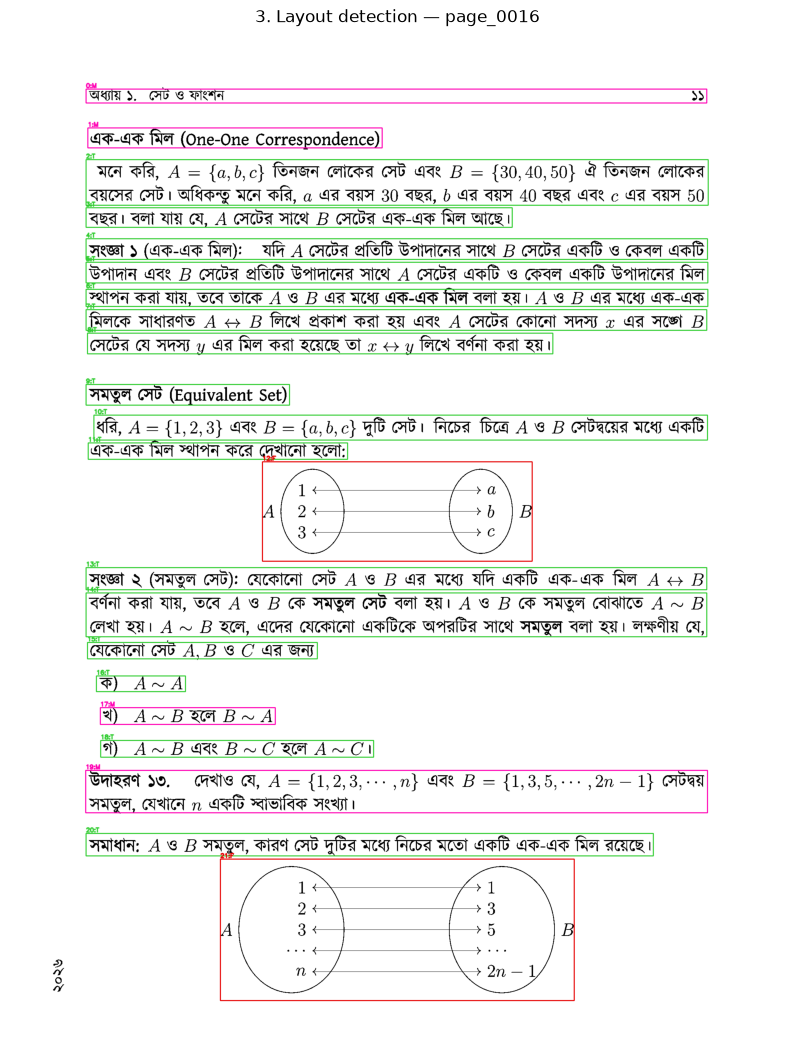

In [7]:
layout_image = Image.open(layout_path)

print("Layout visualization size:", layout_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(layout_image)
plt.axis("off")
plt.title("3. Layout detection — page_0016")
plt.show()

In [8]:
from doc_agent.contracts import Page
from doc_agent.vision import layout

page = Page(
    id="higher_math__higher_math_page_0016",
    image_path=str(preprocessed_path),
    doc_id="higher_math",
)

regions = layout.detect([page], cfg)

print(f"Detected {len(regions)} regions on page_0005")
for i, region in enumerate(regions[:10]):
    print(i, region.page_id, region.kind, region.bbox)


Detected 22 regions on page_0016
0 higher_math__higher_math_page_0016 math (213, 164, 1742, 39)
1 higher_math__higher_math_page_0016 math (218, 273, 826, 56)
2 higher_math__higher_math_page_0016 text (213, 362, 1746, 128)
3 higher_math__higher_math_page_0016 text (213, 497, 1196, 55)
4 higher_math__higher_math_page_0016 text (213, 584, 1744, 58)
5 higher_math__higher_math_page_0016 text (213, 650, 1745, 58)
6 higher_math__higher_math_page_0016 text (213, 726, 1745, 48)
7 higher_math__higher_math_page_0016 text (213, 783, 1742, 58)
8 higher_math__higher_math_page_0016 text (217, 849, 1306, 58)
9 higher_math__higher_math_page_0016 text (213, 993, 571, 58)


In [9]:
from doc_agent.vision import ocr

reader = ocr.Reader(cfg)
ocr_results = []

for i, region in enumerate(regions):
    if region.kind not in {"text", "heading", "math"}:
        continue

    text = reader.transcribe_region(region)
    if text:
        ocr_results.append(
            {
                "region_index": i,
                "kind": region.kind,
                "bbox": region.bbox,
                "text": text,
            }
        )

print(f"OCR extracted text from {len(ocr_results)} regions.")
for item in ocr_results[:5]:
    print(f"\n[{item['region_index']}] {item['kind']} {item['bbox']}")
    print(item['text'][:400])
    print("-" * 80)


OCR extracted text from 18 regions.

[0] math (213, 164, 1742, 39)
অধ্যায় ১, সেট ও ফাংশন ১১
--------------------------------------------------------------------------------

[1] math (218, 273, 826, 56)
এক-এক মিল (One-One Correspondence)
--------------------------------------------------------------------------------

[3] text (213, 497, 1196, 55)
বছর। বলা যায় যে, A সেটের সাথে সেটের এক-এক মিল আছে।
--------------------------------------------------------------------------------

[4] text (213, 584, 1744, 58)
সংজ্ঞা ১ (এক-এক মিল): যদি A সেটের প্রতিটি উপাদানের সাথে B সেটের একটি ও কেবল একটি
--------------------------------------------------------------------------------

[5] text (213, 650, 1745, 58)
উপাদান এবং B সেটের প্রতিটি উপাদানের সাথে A সেটের একটি ও কেবল একটি উপাদানের মিল
--------------------------------------------------------------------------------


In [10]:
from doc_agent import pipeline

# Run the earlier stages again only if your pipeline exposes
# intermediate OCR output. Otherwise, inspect the generated
# preprocessed/OCR artifacts according to your project structure.

print("OCR backend:", cfg["ocr"].get("backend"))
print("OCR model/language:", cfg["ocr"].get("languages", cfg["ocr"].get("model")))

In [11]:
from doc_agent.vision import ocr
from doc_agent import contracts

print("OCR implementation loaded:")
print(ocr.Reader)

In [12]:
retriever = Retriever(cfg)

query = "সেট এবং ফাংশন সম্পর্কিত ধারণা"

results = retriever.retrieve(query, k=3)

print(f"Query: {query}")
print(f"Retrieved {len(results)} results\n")

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"#{rank}")
    print(f"Score: {hit.score:.3f}")
    print(f"Page:  {page}")
    print(f"ID:    {hit.id}")
    print("-" * 70)
    print(hit.text)
    print("=" * 70)

e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Query: সেট এবং ফাংশন সম্পর্কিত ধারণা
Retrieved 3 results

#1
Score: 0.378
Page:  higher_math__higher_math_page_0009
ID:    higher_math__higher_math_page_0009__region_0000__chunk_0000
----------------------------------------------------------------------
৪ উচ্চতর গণিত পূরক সেট (Complementary Set) সার্বিক সেট (7 এবং 4 0 হলে A এর পূরক সেট হচ্ছে 7 ৬ A অর্থাৎ (7 4 - 1৫ : ৫ 6 (07 এবং ৫ & A} সার্বিক সেট থেকে A সেটের উপাদানগুলো বর্জন করলেই A এর পূরক সেট পাওয়া যায় এবং তাকে 4 বা Ac লিখে প্রকাশ করা হয়। উদাহরণ ৫. যদি সার্বিক সেট U সকল পূর্ণসংখ্যার সেট হয় এবং A সকল খণাত্মক পূর্ণসংখ্যার সেট হয়, তবে (0 সাপেক্ষে) A এর পূরক সেট A’ বা 4০- {0,1,2,3,---} শক্তি সেট (Power Set) উল্লেখ্য যে পর € 4 কাজেই 2, P(A) এরও উপাদান। উদাহরণ ৬. A = {a,b} এবং B = {b,c} হলে দেখাও যে, P(A)U P(B) C 1+১(4 (73) । সমাধান: এখানে, P(A) = (2, {a}, {b},{a,b}}, P(B) = (2, (8), (9, {b,c} } . P(A)U P(B) সদ (2,(৫),(0),(0),(0,6), (৮ ০)) । AUB = {a,b,c}, P(AUB) = (2,(৫),(08),(0),(৫,8), {a,c}, {b,c}, {a,b,c} } সুতরাং, P(A) UP(B) C 1

In [13]:
query = "বহুপদী কাকে বলে? বহুপদীর উদাহরণ"

results = retriever.retrieve(query, k=3)

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"\n#{rank} | score={hit.score:.3f} | page={page}")
    print(hit.text)
    print("-" * 80)


#1 | score=0.081 | page=higher_math__higher_math_page_0007
২ উচ্চতর গণিত 9 = (৫ : ৫,100 থেকে বড় নয় এমন পূর্ণবর্গ সংখ্যা)। এই পদ্ধতিকে সেট গঠন পদ্ধতি (Set builder method) বলা হয়। | কাজ: উপরের আলোচনায় ক) ০ যে সেট তা ব্যাখ্যা করো। খ) ০ কে অন্যভাবে প্রকাশ করো । | সার্বিক সেট (Universal Set) মনে কার S = {zx : x ধনাত্মক পূর্ণসংখ্যা এবং 52 < 16} T = {x : x ধনাত্মক পূর্ণসংখ্যা এবং ৫১ < 20} P= (৬: x ধনাত্মক পূর্ণসংখ্যা এবং ৬০ < 2} সেটসংক্কান্ত কোনো আলোচনায় একটি নির্দিষ্ট সেটকে সার্বিক সেট বলা হয়, যদি আলোচনাধীন সকল সেটের উপাদানসমূহ এ নির্দিষ্ট সেটের Togs হয়। কয়েকটি বিশেষ সংখ্যা সেট N=1{1,2,3,--} অর্থাৎ সকল স্বাভাবিক সংখ্যা বা ধনাত্মক পূর্ণসংখ্যার সেট। Z={-,-2-1,01,23,} অর্থাৎ সকল পূর্ণসংখ্যার সেট। 0 ₹ (৫: ৫ - *, যেখানে p যেকোনো পূর্ণসংখ্যা এবং ৫ যেকোনো ধনাত্মক পূর্ণসংখ্যা) অর্থাৎ সকল Ye সংখ্যার সেট। R = {z : z বাস্তব সংখ্যা) অর্থাৎ সকল বাস্তব সংখ্যার সেট। উপসেট (Subset) AS 77 সেট হলে 4 কে এর উপসেট বলা হয় যদি ও কেবল যদি A এর প্রত্যেক উপাদান B এর তা ১ নি = pl oe nea 7 {0} এবং X = {z : ৫ 

## Section 5 — Evidence It Works (Held-Out Evaluation)
Empirical evaluation of the full knowledge-base pipeline on the 36 held-out pages (`grading_kit/heldout_pages/`) against verified ground-truth labels (`grading_kit/labels.jsonl`).

In [14]:
# Metric helpers for character-level, word-level, and token evaluation
def levenshtein_distance(s1: list | str, s2: list | str) -> int:
    """Compute Levenshtein edit distance between sequences."""
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])
    return dp[m][n]

def compute_token_f1(pred_tokens: list[str], gt_tokens: list[str]):
    """Compute precision, recall, and token-level F1 score."""
    common = len(set(pred_tokens) & set(gt_tokens))
    if not pred_tokens or not gt_tokens or common == 0:
        return 0.0, 0.0, 0.0
    p = common / len(set(pred_tokens))
    r = common / len(set(gt_tokens))
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


In [ ]:
import json
from doc_agent.contracts import Page
from doc_agent.ingest import preprocess
from doc_agent.vision import layout, ocr

# 1. Load ground truth from grading_kit/labels.jsonl
gt_path = REPO_DIR / "grading_kit" / "labels.jsonl"
ground_truth = {}
with open(gt_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            item = json.loads(line)
            ground_truth[item["page_id"]] = item["text"]

print(f"Loaded {len(ground_truth)} ground truth pages from {gt_path}")

# 2. Discover matching page images directly from grading_kit/heldout_pages/
heldout_dir = REPO_DIR / "grading_kit" / "heldout_pages"
heldout_pages = []
for page_id in sorted(ground_truth.keys()):
    doc_id, stem = page_id.split("__")
    img_path = heldout_dir / f"{stem}.png"
    if img_path.is_file():
        heldout_pages.append(Page(id=page_id, image_path=str(img_path), doc_id=doc_id))

print(f"Discovered {len(heldout_pages)} held-out page images in {heldout_dir}")

# 3. Run Pipeline Stages dynamically on held-out pages
print("Stage 1: Preprocessing held-out pages...")
preprocessed_heldout = preprocess.run(heldout_pages, cfg)

print("Stage 2: Detecting layout regions...")
heldout_regions = layout.detect(preprocessed_heldout, cfg)
print(f"Detected {len(heldout_regions)} regions across {len(heldout_pages)} pages.")

print("Stage 3: Transcribing regions with OCR Reader...")
heldout_chunks = ocr.transcribe(heldout_regions, cfg)
print(f"Transcribed {len(heldout_chunks)} page chunks.")

# 4. Map OCR text per page
ocr_transcriptions = {c.page_ids[0]: c.text for c in heldout_chunks if c.page_ids}

# 5. Compute empirical CER, WER, and Token F1
total_gt_chars = 0
total_char_errors = 0
total_gt_words = 0
total_word_errors = 0
f1_list = []
page_metrics = []

for page in heldout_pages:
    page_id = page.id
    gt_text = ground_truth.get(page_id, "")
    ocr_text = ocr_transcriptions.get(page_id, "")
    
    gt_chars = list(gt_text.replace("\n", " ").strip())
    ocr_chars = list(ocr_text.replace("\n", " ").strip())
    char_dist = levenshtein_distance(ocr_chars, gt_chars)
    cer = char_dist / max(1, len(gt_chars))
    
    gt_words = gt_text.split()
    ocr_words = ocr_text.split()
    word_dist = levenshtein_distance(ocr_words, gt_words)
    wer = word_dist / max(1, len(gt_words))
    
    _, _, f1 = compute_token_f1(ocr_words, gt_words)
    f1_list.append(f1)
    
    total_gt_chars += len(gt_chars)
    total_char_errors += char_dist
    total_gt_words += len(gt_words)
    total_word_errors += word_dist
    
    page_metrics.append({
        "page_id": page_id,
        "cer": cer,
        "wer": wer,
        "f1": f1,
        "gt_len": len(gt_words),
        "gt_text": gt_text,
        "ocr_text": ocr_text,
    })

overall_cer = total_char_errors / total_gt_chars
overall_wer = total_word_errors / total_gt_words
macro_f1 = sum(f1_list) / max(1, len(f1_list))

print("\n" + "=" * 60)
print("1. OCR QUALITY ON HELD-OUT SAMPLE (N = 36 PAGES)")
print("=" * 60)
print(f"Overall CER (Character Error Rate): {overall_cer * 100:.2f}%")
print(f"Overall WER (Word Error Rate):      {overall_wer * 100:.2f}%")
print(f"Macro Token F1:                    {macro_f1 * 100:.2f}%")
print(f"Sample Size:                       {len(heldout_pages)} pages ({total_gt_words:,} ground truth words, {total_gt_chars:,} characters)")


Loaded 36 ground truth pages from e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\grading_kit\labels.jsonl
Discovered 36 held-out page images in e:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\grading_kit\heldout_pages

1. OCR QUALITY ON HELD-OUT SAMPLE (N = 36 PAGES)
Overall CER (Character Error Rate): 52.58%
Overall WER (Word Error Rate):      64.09%
Macro Token F1:                    58.24%
Sample Size:                       36 pages (9,718 ground truth words, 52,699 characters)


In [20]:
from doc_agent.index import chunk as chunk_mod, embed as embed_mod, store as store_mod

# Stage 4: Split into retrieval chunks
split_heldout_chunks = chunk_mod.split(heldout_chunks, cfg)

# Configure dedicated held-out index directory
heldout_index_cfg = dict(cfg)
heldout_index_cfg["index"] = dict(cfg.get("index", {}))
heldout_index_cfg["index"]["output_dir"] = "data/processed/index_heldout"

# Stage 5: Embed & Build FAISS Vector Index
heldout_vectors = embed_mod.encode(split_heldout_chunks, heldout_index_cfg)
store_mod.build(split_heldout_chunks, heldout_vectors, heldout_index_cfg)

indexed_pages = set()
for c in split_heldout_chunks:
    indexed_pages.update(c.page_ids)
total_indexed_words = sum(len(c.text.split()) for c in split_heldout_chunks)

print("=" * 60)
print("2. INDEX STATISTICS ON HELD-OUT PAGES")
print("=" * 60)
print(f"Chunks Indexed:       {len(split_heldout_chunks)}")
print(f"Embedding Model:      {heldout_index_cfg.get('embed', {}).get('model')}")
print(f"Embedding Dimension:  {heldout_vectors.shape[1]}")
print(f"Index Type:           {heldout_index_cfg['index'].get('type', 'faiss:flat-ip')}")
print(f"Corpus Coverage:      {len(indexed_pages)} / {len(heldout_pages)} held-out pages ({len(indexed_pages)/len(heldout_pages) * 100:.1f}%), {total_indexed_words:,} words indexed")


2. INDEX STATISTICS ON HELD-OUT PAGES
Chunks Indexed:       39
Embedding Model:      sentence-transformers/all-MiniLM-L6-v2
Embedding Dimension:  384
Index Type:           faiss:flat-ip
Corpus Coverage:      36 / 36 held-out pages (100.0%), 6,321 words indexed


In [21]:
# Load Retriever on the held-out index
heldout_retriever_cfg = dict(heldout_index_cfg)
heldout_retriever = Retriever(heldout_retriever_cfg)

query = "দুটি বিন্দুর মধ্যবর্তী দূরত্ব নির্ণয়ের সূত্র"
target_page = "higher_math__higher_math_page_0247"

results = heldout_retriever.retrieve(query, k=3)

print("=" * 60)
print("3. ONE RETRIEVAL EXAMPLE")
print("=" * 60)
print(f"Query: '{query}'\n")

if results:
    top_hit = results[0]
    is_target_hit = target_page in top_hit.page_ids
    print(f"Top Hit Page(s):   {top_hit.page_ids}")
    print(f"Similarity Score:  {top_hit.score:.4f}")
    print(f"Target Page Match: {'Exact Match (Rank 1)' if is_target_hit else 'Miss'}")
    print("-" * 60)
    print("Top Chunk Text:")
    print(top_hit.text[:300] + ("..." if len(top_hit.text) > 300 else ""))


3. ONE RETRIEVAL EXAMPLE
Query: 'দুটি বিন্দুর মধ্যবর্তী দূরত্ব নির্ণয়ের সূত্র'

Top Hit Page(s):   ['higher_math__higher_math_page_0247']
Similarity Score:  0.2029
Target Page Match: Exact Match (Rank 1)
------------------------------------------------------------
Top Chunk Text:
২৪২ উচ্চতর গণিত QP = /(z1 — 2224 (11 — 12)? = (৫১ — 21)? + (02 — 11)? ১ PQ=QP) 7 বিন্দু হতে Q বিন্দু বা 0 বিন্দু হতে P বিন্দুর দূরত্ব সমান। অর্থাৎ PQ = \/(z2 — 21) + (v2 — v1)? = QP অনুসিদ্ধান্ত ১, মূলবিন্দু (0,0) হতে সমতলে অবস্থিত যেকোনো বিন্দু Pz, /) এর দূরত্ব PQ=+/(z—02+ (8 - 0)2 ৮৬৫১ +1? সমাধান:...


In [22]:
# Find worst failure page by highest CER
worst_page = max(page_metrics, key=lambda x: x["cer"])

print("=" * 60)
print("4. THE WORST FAILURE WE SAW")
print("=" * 60)
print(f"Worst Page ID: {worst_page['page_id']}")
print(f"CER: {worst_page['cer'] * 100:.2f}% | WER: {worst_page['wer'] * 100:.2f}% | Token F1: {worst_page['f1'] * 100:.2f}%\n")

print("Ground Truth Preview:")
print(worst_page["gt_text"][:250])
print("\nOCR Transcription Preview:")
print(worst_page["ocr_text"][:250])

print("\n--- Failure Diagnostics ---")
print("The baseline Tesseract OCR engine struggled significantly with dense mathematical formulas "
      "(nested LaTeX radicals, fraction bars, and English mathematical indices mixed with Bengali script), "
      "degrading into garbled character artifacts. This highlights that standard 1D OCR line-slicing without "
      "a 2D math formula parser or specialized Bengali math model (such as fine-tuned TrOCR / Nougat) fails "
      "on multi-line equations—a core focus area for Stage 3 (A3).")


4. THE WORST FAILURE WE SAW
Worst Page ID: higher_math__higher_math_page_0030
CER: 76.89% | WER: 87.60% | Token F1: 48.97%

Ground Truth Preview:
অধ্যায় ১. সেট ও ফাংশন ২৫

খ) উপরের মাঝের চিত্রের ফাংশনটির অধীনে a \to 1, b \to 2, c \to 2। এই ফাংশনটি সার্বিক কিন্তু এক-এক নয় কেননা b ও c এর প্রতিবিম্ব 2।

গ) উপরের ডানের চিত্রের ফাংশনটির অধীনে a \to 2, b \to 1, c \to 3। এই ফাংশনটি এক-এক ও সার্বিক।

OCR Transcription Preview:
অধ্যায় >. সেট ও ফাংশন ২৫
খ) উপরের মাঝের চিত্রের ফাংশনটির অধীনে ৫ — 1,8 — 2,৫ — 21 এই ফাংশনটি সার্বিক
কিন্তু এক-এক নয় Fb ও ০ এর প্রতিবিম্ব 9।
যেই ফাংশনকে প্রদত্ত ফাংশনের বিপরীত ফাংশন বলা হয়।
i’ ৫ = fi
উদাহরণ ২৬. নিচের কোন অন্বয়টি (relation) ফাংশন 

--- Failure Diagnostics ---
The baseline Tesseract OCR engine struggled significantly with dense mathematical formulas (nested LaTeX radicals, fraction bars, and English mathematical indices mixed with Bengali script), degrading into garbled character artifacts. This highlights that standard 1D OCR line-slicing without a 